# Setup and Imports


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.data.load_data import load_data
from src.models.train import build_decision_tree_pipeline
from src.models.train import build_random_forest_pipeline
from src.models.train import build_xgboost_pipeline


# Load and Prepare Data


In [2]:
df_raw, df = load_data()


In [3]:
columns_to_drop = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

df = df.drop(columns=columns_to_drop)

X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]


# Train/Test Split


In [4]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)


# Decision Tree Tuning


In [5]:
dt_depth_pipeline = build_decision_tree_pipeline()

dt_depth_param_grid = {
    "model__max_depth": [5, 7, 8, 10, 15],
}

dt_depth_grid_search = GridSearchCV(
    estimator=dt_depth_pipeline,
    param_grid=dt_depth_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

dt_depth_grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 7, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, wit

In [6]:
print("Best parameters:", dt_depth_grid_search.best_params_)
print("Best CV F1-score:", dt_depth_grid_search.best_score_)


Best parameters: {'model__max_depth': 10}
Best CV F1-score: 0.7188837231975918


In [7]:
dt_pipeline = build_decision_tree_pipeline()

dt_param_grid = {
    "model__max_depth": [7, 10, 11, 12, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

dt_grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

dt_grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [7, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [8]:
print("Best parameters:", dt_grid_search.best_params_)
print("Best CV F1-score:", dt_grid_search.best_score_)


Best parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}
Best CV F1-score: 0.7209388077983055


In [9]:
best_dt_model = dt_grid_search.best_estimator_

tuned_dt_predictions = best_dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, tuned_dt_predictions))
print(classification_report(y_test, tuned_dt_predictions))
print(confusion_matrix(y_test, tuned_dt_predictions))


Accuracy: 0.9855
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.80      0.76      0.78        68

    accuracy                           0.99      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.99      0.99      0.99      2000

[[1919   13]
 [  16   52]]


In [10]:
tuned_dt_train_predictions = best_dt_model.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(y_train, tuned_dt_train_predictions),
)

print(
    "Testing Accuracy:",
    accuracy_score(y_test, tuned_dt_predictions),
)


Training Accuracy: 0.98975
Testing Accuracy: 0.9855


In [11]:
dt_preprocessor = best_dt_model.named_steps["preprocessor"]
decision_tree_model = best_dt_model.named_steps["model"]


In [12]:
dt_feature_names = dt_preprocessor.get_feature_names_out()


In [13]:
dt_feature_importance = pd.DataFrame(
    {
        "feature": dt_feature_names,
        "importance": decision_tree_model.feature_importances_,
    }
).sort_values(
    by="importance",
    ascending=False,
)

dt_feature_importance


,feature,importance
6,numerical__Torque [Nm],0.423881
3,numerical__Air temperature [K],0.209686
7,numerical__Tool wear [min],0.148298
4,numerical__Process temperature [K],0.109744
5,numerical__Rotational speed [rpm],0.092488
1,categorical__Type_L,0.012167
2,categorical__Type_M,0.003736
0,categorical__Type_H,0.000000


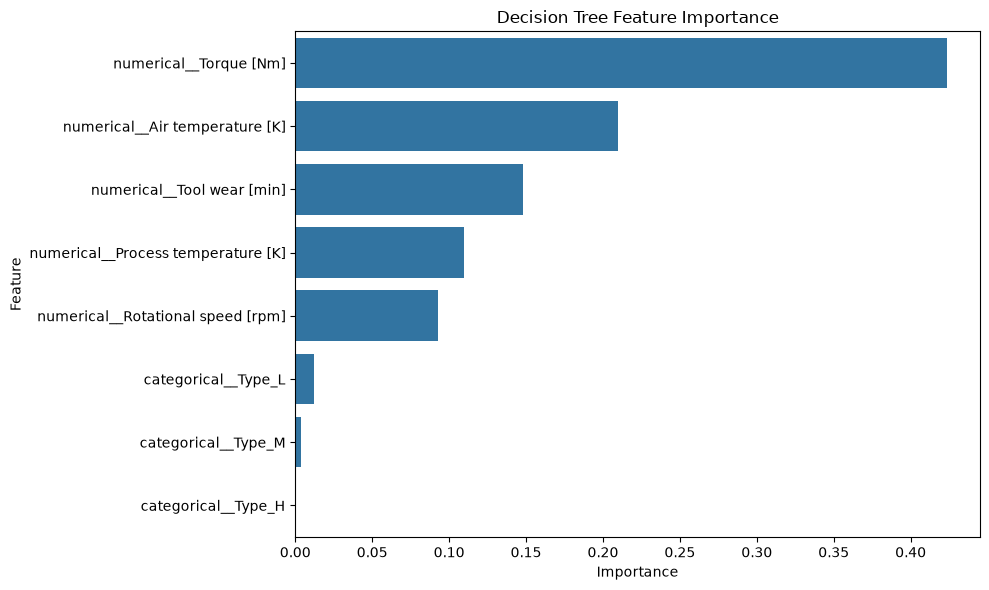

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dt_feature_importance,
    x="importance",
    y="feature",
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [15]:
dt_permutation_result = permutation_importance(
    best_dt_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)


In [16]:
dt_permutation_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": dt_permutation_result.importances_mean,
        "importance_std": dt_permutation_result.importances_std,
    }
).sort_values(
    by="importance_mean",
    ascending=False,
)

dt_permutation_df


,feature,importance_mean,importance_std
4,Torque [Nm],0.392971,0.020510
1,Air temperature [K],0.350369,0.043107
3,Rotational speed [rpm],0.314316,0.021459
5,Tool wear [min],0.166262,0.018039
2,Process temperature [K],0.148388,0.015236
0,Type,0.028494,0.021403


# Random Forest Tuning


In [17]:
rf_pipeline = build_random_forest_pipeline()

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": [None, "balanced"],
}


rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

rf_grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [10, 15, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [18]:
print("Best parameters:", rf_grid_search.best_params_)
print("Best CV F1-score:", rf_grid_search.best_score_)


Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV F1-score: 0.6921694893640336


In [19]:
best_rf_model = rf_grid_search.best_estimator_

tuned_rf_predictions = best_rf_model.predict(X_test)
tuned_rf_train_predictions = best_rf_model.predict(X_train)

print("Accuracy:", accuracy_score(y_test, tuned_rf_predictions))
print(classification_report(y_test, tuned_rf_predictions))
print(confusion_matrix(y_test, tuned_rf_predictions))

print("Training Accuracy:", accuracy_score(y_train, tuned_rf_train_predictions))
print("Testing Accuracy :", accuracy_score(y_test, tuned_rf_predictions))


Accuracy: 0.9795
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.66      0.69        68

    accuracy                           0.98      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.98      0.98      0.98      2000

[[1914   18]
 [  23   45]]
Training Accuracy: 0.99975
Testing Accuracy : 0.9795


# XGBoost scale_pos_weight Experiment


In [20]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(scale_pos_weight)


28.52029520295203


In [21]:
xgb_weight_pipeline = build_xgboost_pipeline()

xgb_weight_param_grid = {
    "model__scale_pos_weight": [1, 3, 5],
}

xgb_weight_grid_search = GridSearchCV(
    estimator=xgb_weight_pipeline,
    param_grid=xgb_weight_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

xgb_weight_grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__scale_pos_weight': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fit

In [22]:
print("Best parameters:", xgb_weight_grid_search.best_params_)
print("Best CV F1-score:", xgb_weight_grid_search.best_score_)


Best parameters: {'model__scale_pos_weight': 5}
Best CV F1-score: 0.7467151017070449


# Full XGBoost Hyperparameter Tuning


In [23]:
xgb_pipeline = build_xgboost_pipeline()

xgb_param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__scale_pos_weight": [1, 3, 5],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)

xgb_grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], 'model__scale_pos_weight': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support

In [24]:
print(
    "Best parameters:",
    xgb_grid_search.best_params_,
)

print(
    "Best CV F1-score:",
    xgb_grid_search.best_score_,
)


Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__n_estimators': 400, 'model__scale_pos_weight': 3}
Best CV F1-score: 0.7547529376467681


# Tuned Model Evaluation


In [25]:
best_xgb_model = xgb_grid_search.best_estimator_

tuned_xgb_predictions = best_xgb_model.predict(X_test)
tuned_xgb_train_predictions = best_xgb_model.predict(X_train)

print(
    "Accuracy:",
    accuracy_score(y_test, tuned_xgb_predictions),
)

print(
    classification_report(
        y_test,
        tuned_xgb_predictions,
    )
)

print(
    confusion_matrix(
        y_test,
        tuned_xgb_predictions,
    )
)

print(
    "Training Accuracy:",
    accuracy_score(
        y_train,
        tuned_xgb_train_predictions,
    ),
)

print(
    "Testing Accuracy:",
    accuracy_score(
        y_test,
        tuned_xgb_predictions,
    ),
)


Accuracy: 0.9855
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.83      0.72      0.77        68

    accuracy                           0.99      2000
   macro avg       0.91      0.86      0.88      2000
weighted avg       0.98      0.99      0.99      2000

[[1922   10]
 [  19   49]]
Training Accuracy: 1.0
Testing Accuracy: 0.9855


# Final Model Comparison


In [26]:
comparison_rows = []

if "tuned_dt_predictions" in globals():
    comparison_rows.append(
        {
            "model": "Tuned Decision Tree",
            "accuracy": accuracy_score(y_test, tuned_dt_predictions),
            "precision_class_1": precision_score(y_test, tuned_dt_predictions, pos_label=1),
            "recall_class_1": recall_score(y_test, tuned_dt_predictions, pos_label=1),
            "f1_class_1": f1_score(y_test, tuned_dt_predictions, pos_label=1),
        }
    )

if "tuned_rf_predictions" in globals():
    comparison_rows.append(
        {
            "model": "Tuned Random Forest",
            "accuracy": accuracy_score(y_test, tuned_rf_predictions),
            "precision_class_1": precision_score(y_test, tuned_rf_predictions, pos_label=1),
            "recall_class_1": recall_score(y_test, tuned_rf_predictions, pos_label=1),
            "f1_class_1": f1_score(y_test, tuned_rf_predictions, pos_label=1),
        }
    )

if "tuned_xgb_predictions" in globals():
    comparison_rows.append(
        {
            "model": "Tuned XGBoost",
            "accuracy": accuracy_score(y_test, tuned_xgb_predictions),
            "precision_class_1": precision_score(y_test, tuned_xgb_predictions, pos_label=1),
            "recall_class_1": recall_score(y_test, tuned_xgb_predictions, pos_label=1),
            "f1_class_1": f1_score(y_test, tuned_xgb_predictions, pos_label=1),
        }
    )

final_model_comparison = pd.DataFrame(comparison_rows)
final_model_comparison


,model,accuracy,precision_class_1,recall_class_1,f1_class_1
0,Tuned Decision Tree,0.9855,0.800000,0.764706,0.781955
1,Tuned Random Forest,0.9795,0.714286,0.661765,0.687023
2,Tuned XGBoost,0.9855,0.830508,0.720588,0.771654
